In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy import stats
import os

### Loading the data

In [2]:
df = pd.read_csv('../data/nigeria.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


## **Data Loading & Date Parsing**

### Add a Country column with the Ethiopia value

In [3]:
df_clean = df.copy()

In [4]:
df_clean["Country"] = "Nigeria"
df_clean.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria


### Convert the YEAR and DOY columns into a proper datetime column

In [5]:
df_clean["Date"] = pd.to_datetime(df_clean["YEAR"] * 1000 + df_clean["DOY"], format="%Y%j")
df_clean.drop(columns=["YEAR", "DOY"], inplace=True)
df_clean.sample(5)


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
3309,27.80,30.74,25.30,5.44,0.16,79.95,2.22,2.67,101.05,18.50,Nigeria,2024-01-23
2987,27.97,30.45,25.92,4.53,2.07,82.49,2.61,3.35,100.58,19.40,Nigeria,2023-03-07
2675,26.74,28.23,25.69,2.54,10.02,83.40,0.88,1.74,100.76,18.29,Nigeria,2022-04-29
1554,28.53,30.95,26.88,4.07,8.34,86.29,2.51,2.85,100.47,21.02,Nigeria,2019-04-04
1908,27.02,28.24,25.91,2.33,10.02,89.66,2.65,3.87,100.76,19.98,Nigeria,2020-03-23


### Extract Month as a separate colum

In [6]:
df_clean["Month"] = df_clean["Date"].dt.month
df_clean.sample(5)

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
2771,24.30,27.20,22.32,4.88,0.26,85.63,2.77,3.62,100.89,16.16,Nigeria,2022-08-03,8
3925,25.88,27.81,24.69,3.12,5.32,91.77,2.25,2.92,101.01,19.07,Nigeria,2025-09-30,9
1919,27.42,29.32,25.88,3.44,1.22,87.83,2.54,3.31,100.62,20.04,Nigeria,2020-04-03,4
1430,27.55,29.58,26.00,3.58,0.31,85.05,1.89,2.35,100.70,19.54,Nigeria,2018-12-01,12
1662,25.33,27.70,23.59,4.11,3.43,90.14,2.55,3.30,101.03,18.08,Nigeria,2019-07-21,7


## **Summary Statistics & Missing-Value Report**

#### Replace all occurrences of -999 with np.nan

In [7]:
df_clean.replace(-999, np.nan, inplace=True)
df_clean.sample(5)

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
4059,26.99,29.94,24.32,5.62,1.24,83.06,1.99,2.24,100.91,18.35,Nigeria,2026-02-11,2
724,27.96,31.23,25.15,6.08,0.00,80.17,1.39,2.18,100.59,18.73,Nigeria,2016-12-25,12
3654,28.05,31.62,25.55,6.07,0.02,81.91,1.66,2.19,100.66,19.22,Nigeria,2025-01-02,1
616,25.63,28.01,24.01,4.00,4.53,89.94,2.91,3.74,101.03,18.37,Nigeria,2016-09-08,9
3071,27.55,29.05,26.58,2.47,3.64,85.33,1.99,2.70,100.91,19.59,Nigeria,2023-05-30,5


In [8]:
df_clean.isna().sum()

T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

### Handle duplicate rows

In [9]:
# drop any duplicate rows
df_clean.duplicated().sum()


0

In [10]:
df_clean.describe()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


## **Outlier Detection & Basic Cleaning**

### Detect outliers using z-score

In [11]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df_clean[cols_to_check]))

In [12]:
outliers_mask=(z_scores>3).any(axis=1)
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 225


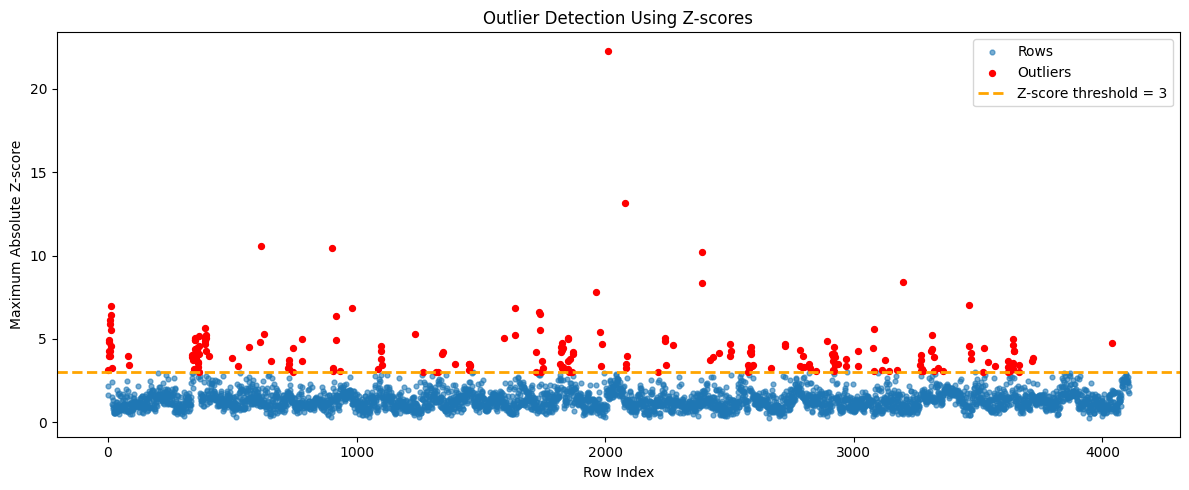

In [13]:
max_z = np.abs(z_scores).max(axis=1)

plt.figure(figsize=(12, 5))
plt.scatter(df_clean.index, max_z, s=12, alpha=0.6, label="Rows")
plt.scatter(df_clean.index[outliers_mask], max_z[outliers_mask], color="red", s=18, label="Outliers")
plt.axhline(3, color="orange", linestyle="--", linewidth=2, label="Z-score threshold = 3")
plt.title("Outlier Detection Using Z-scores")
plt.xlabel("Row Index")
plt.ylabel("Maximum Absolute Z-score")
plt.legend()
plt.tight_layout()
plt.show()

### 🧹 Outlier Handling Strategy

Outliers were identified using Z-scores, with a threshold of (|Z| > 3). Rather than removing all outliers indiscriminately, a domain-aware approach was applied to distinguish between data errors, noise, and meaningful extreme weather events.

#### 1. Dropping Invalid Observations

Rows were **dropped** only when they violated known physical or logical constraints:

* ( T2M_MAX < T2M_MIN )
* ( T2M_RANGE \neq T2M_MAX - T2M_MIN )
* Relative humidity ((RH2M)) outside the range ([0, 100])
* Negative wind speed values

These represent data inconsistencies or measurement errors rather than true outliers.
In our case no such data was found. 

---

#### 2. Retaining Multi-variable Outliers

Rows where **two or more variables simultaneously exceeded the Z-score threshold** were **retained**. These accounted for approximately **1% of the dataset (6 rows)**.

These observations are likely to represent **real meteorological events**, such as:

* Storms (e.g., high wind speed and high precipitation)
* Temperature anomalies (e.g., unusually hot or cold days)

For example, **8 rows were identified as storm event and 4 as heat event**, characterized by concurrent high values in `WS2M_MAX` and `PRECTOTCORR`. Such patterns are physically meaningful and should be preserved.
we have also seen all outliers might be rearly extreme values so the data outliers were all retained.

---

#### 3. Capping Single-variable Outliers

Rows where **only one variable exceeded the Z-score threshold** were treated as potential noise or measurement spikes. Instead of removing these rows, the extreme values were **capped** using percentile-based clipping (1st and 99th percentiles).

This approach:

* Reduces the impact of extreme values on analysis and modeling
* Preserves the overall structure and continuity of the dataset

In the data there were no single variable outliers

---

#### **Final Strategy Summary**

| Category                               | Action     | Rationale          |
| -------------------------------------- | ---------- | ------------------ |
| Physically inconsistent values         | **Drop**   | Data errors        |
| Multi-variable outliers (≥2 variables) | **Retain** | Likely real events |
| Single-variable outliers               | **Cap**    | Likely noise       |

---

This approach ensures that important extreme weather patterns are preserved while minimizing the influence of erroneous or noisy data points.


In [29]:
outlier_counts = pd.Series((z_scores > 3).sum(axis=0), index=cols_to_check)
total_rows_per_col = df_clean[cols_to_check].notna().sum(axis=0)

outlier_counts = pd.DataFrame({
    "Outlier_Count": outlier_counts,
    "Outlier_Percentage (%)": (outlier_counts / total_rows_per_col) * 100
})

print(outlier_counts)

             Outlier_Count  Outlier_Percentage (%)
T2M                     10                0.243427
T2M_MAX                  1                0.024343
T2M_MIN                 68                1.655307
PRECTOTCORR             75                1.825706
RH2M                   128                3.115871
WS2M                     5                0.121714
WS2M_MAX                10                0.243427


### Detecting Invalid Observations

In [30]:
# Data quality checks
humidity_col = "RH2M" if "RH2M" in df_clean.columns else "Humidity"
wind_col = "WS2M" if "WS2M" in df_clean.columns else "Wind speed"

checks = pd.DataFrame(index=df_clean.index)

# 1) T2M_MAX < T2M_MIN
checks["T2M_MAX_lt_T2M_MIN"] = df_clean["T2M_MAX"] < df_clean["T2M_MIN"]

# 2) T2M_RANGE != T2M_MAX - T2M_MIN
expected_range = df_clean["T2M_MAX"] - df_clean["T2M_MIN"]
checks["T2M_RANGE_mismatch"] = ~np.isclose(df_clean["T2M_RANGE"], expected_range, equal_nan=True)

# 3) Humidity < 0 or > 100
checks["Humidity_out_of_bounds"] = (df_clean[humidity_col] < 0) | (df_clean[humidity_col] > 100)

# 4) Wind speed < 0
checks["Wind_speed_negative"] = df_clean[wind_col] < 0

# Combine and report
checks["any_issue"] = checks.any(axis=1)

print("Issue counts by rule:")
print(checks.drop(columns="any_issue").sum())

print(f"\nTotal rows with at least one issue: {checks['any_issue'].sum()}")

# Show problematic rows with relevant columns
problem_rows = df_clean.loc[
    checks["any_issue"],
    [c for c in ["Date", "T2M_MIN", "T2M_MAX", "T2M_RANGE", humidity_col, wind_col] if c in df_clean.columns]
].copy()

problem_rows["T2M_MAX_lt_T2M_MIN"] = checks.loc[checks["any_issue"], "T2M_MAX_lt_T2M_MIN"].values
problem_rows["T2M_RANGE_mismatch"] = checks.loc[checks["any_issue"], "T2M_RANGE_mismatch"].values
problem_rows["Humidity_out_of_bounds"] = checks.loc[checks["any_issue"], "Humidity_out_of_bounds"].values
problem_rows["Wind_speed_negative"] = checks.loc[checks["any_issue"], "Wind_speed_negative"].values

if not problem_rows.empty:
    print(problem_rows.head(10))

Issue counts by rule:
T2M_MAX_lt_T2M_MIN        0
T2M_RANGE_mismatch        0
Humidity_out_of_bounds    0
Wind_speed_negative       0
dtype: int64

Total rows with at least one issue: 0


In [31]:
df_temp = df_clean.copy()

In [32]:
df_temp["is_outlier"] = outliers_mask
df_temp["outlier_count"] = df_temp[cols_to_check].apply(lambda row: (row > 3).sum(), axis=1)

### Detect Multi-variable Outliers

In [33]:
T2M_idx = cols_to_check.index("T2M")
T2M_MAX_idx = cols_to_check.index("T2M_MAX")
T2M_MIN_idx = cols_to_check.index("T2M_MIN")
WS2M_MAX_idx = cols_to_check.index("WS2M_MAX")
PRECTOTCORR_idx = cols_to_check.index("PRECTOTCORR")
RH2M_idx = cols_to_check.index("RH2M")

df_temp["heatwave_flag"] = (
    df_temp["is_outlier"] &
    (z_scores[:, T2M_idx] > 2) &
    (z_scores[:, T2M_MAX_idx] > 2) &
    (z_scores[:, T2M_MIN_idx] > 2)
)

df_temp["storm_flag"] = (
    df_temp["is_outlier"] &
    (z_scores[:, WS2M_MAX_idx] > 2) &
    (z_scores[:, PRECTOTCORR_idx] > 2) &
    (df_temp["RH2M"] > 70)
)

In [34]:
heatwaves = df_temp["heatwave_flag"].sum()
storms = df_temp["storm_flag"].sum()
print("Number of heatwave days:", heatwaves)
print("Number of Storm days:", storms)

Number of heatwave days: 4
Number of Storm days: 8


In [35]:
outlier_mask = df_temp["is_outlier"]
outlier_df = df_temp.loc[outlier_mask]

# Run consistency checks only on outlier rows
temp_consistency = (
    (outlier_df["T2M_MIN"] <= outlier_df["T2M"]) &
    (outlier_df["T2M"] <= outlier_df["T2M_MAX"]) &
    (np.abs(outlier_df["T2M_RANGE"] - (outlier_df["T2M_MAX"] - outlier_df["T2M_MIN"])) < 1e-3)
)

wind_consistency = outlier_df["WS2M"] <= outlier_df["WS2M_MAX"]
humidity_consistency = (outlier_df["RH2M"] >= 0) & (outlier_df["RH2M"] <= 100)

p95_rain = outlier_df["PRECTOTCORR"].quantile(0.95)
storm_consistency = ~(
    (outlier_df["PRECTOTCORR"] > p95_rain) &
    (outlier_df["RH2M"] < 30)  # suspicious: heavy rain but very dry air
)

relationship_valid_outliers = (
    temp_consistency &
    wind_consistency &
    humidity_consistency &
    storm_consistency
)

# Map back to full index (non-outliers set to False)
relationship_valid = pd.Series(False, index=df_temp.index)
relationship_valid.loc[outlier_df.index] = relationship_valid_outliers

# Keep multi-variable logic within outliers only
multi_mask = outlier_mask & (df_temp["outlier_count"] >= 2)

valid_multi = multi_mask & relationship_valid
invalid_multi = multi_mask & ~relationship_valid

print("Outlier rows checked:", outlier_mask.sum())
print("Valid multi-variable outliers:", valid_multi.sum())
print("Invalid multi-variable outliers:", invalid_multi.sum())

Outlier rows checked: 225
Valid multi-variable outliers: 225
Invalid multi-variable outliers: 0


## Handle remaining missing values

In [36]:
# check missing values
df_clean.isna().sum()

T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

## Export the cleaned DataFrame

In [37]:
df_clean.head()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


In [38]:
os.makedirs("data", exist_ok=True)

country = "ethiopia"
output_path = f"data/{country}_clean.csv"

print("Saving to:", os.path.abspath(output_path))

df_clean.to_csv(output_path, index=False)

print("Exists after save:", os.path.exists(output_path))
df_temp = pd.read_csv('data/ethiopia_clean.csv')
df_temp.head()


Saving to: /home/melki/Desktop/tenx/climate-challenge-week0/notebooks/data/ethiopia_clean.csv
Exists after save: True


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


# **Time Series Analysis**

In [39]:
df_clean["Month"].value_counts()

Month
1     372
3     372
5     341
7     341
8     341
10    341
12    341
2     339
4     330
6     330
9     330
11    330
Name: count, dtype: int64

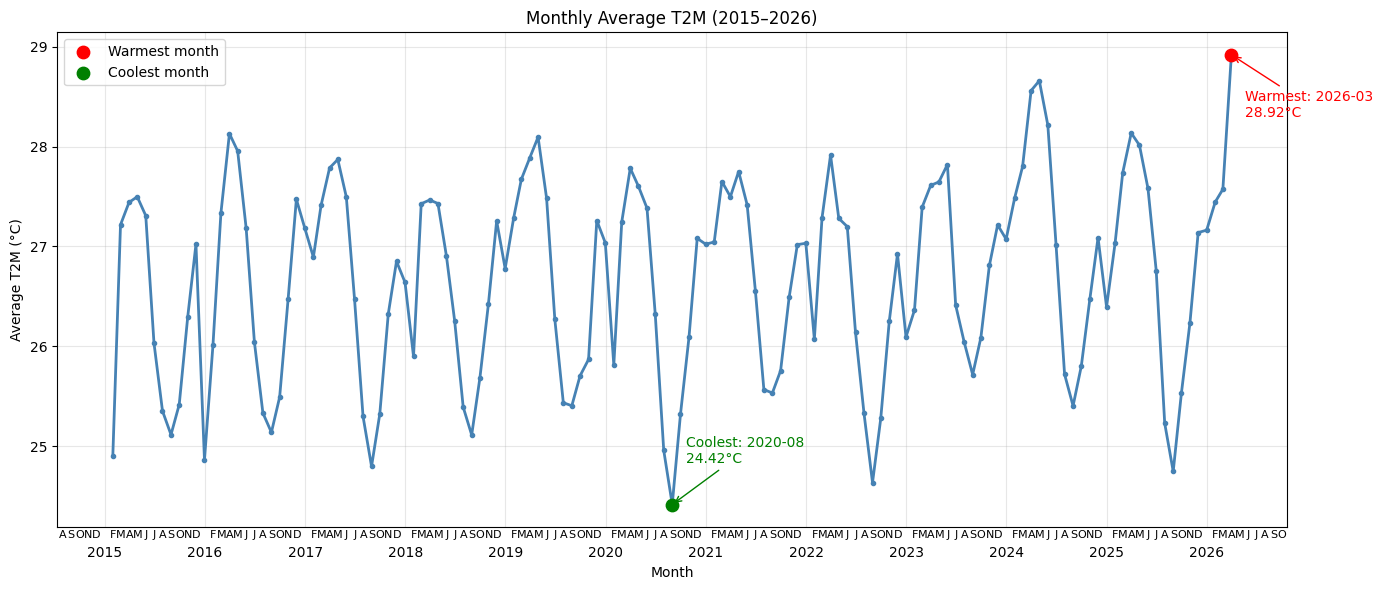

In [40]:
monthly_avg_t2m = df_clean.set_index("Date")["T2M"].resample("ME").mean()

warmest_month = monthly_avg_t2m.idxmax()
coolest_month = monthly_avg_t2m.idxmin()

plt.figure(figsize=(14, 6))
plt.plot(
    monthly_avg_t2m.index,
    monthly_avg_t2m.values,
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=3
)

plt.scatter([warmest_month], [monthly_avg_t2m[warmest_month]], color="red", s=80, zorder=5, label="Warmest month")
plt.scatter([coolest_month], [monthly_avg_t2m[coolest_month]], color="green", s=80, zorder=5, label="Coolest month")

plt.annotate(
    f"Warmest: {warmest_month.strftime('%Y-%m')}\n{monthly_avg_t2m[warmest_month]:.2f}°C",
    xy=(warmest_month, monthly_avg_t2m[warmest_month]),
    xytext=(10, -45),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red"
)

plt.annotate(
    f"Coolest: {coolest_month.strftime('%Y-%m')}\n{monthly_avg_t2m[coolest_month]:.2f}°C",
    xy=(coolest_month, monthly_avg_t2m[coolest_month]),
    xytext=(10, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="green"),
    color="green"
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, pos: mdates.num2date(x).strftime("%b")[0]))

ax.tick_params(axis="x", which="major", length=0, pad=14, labelsize=10)
ax.tick_params(axis="x", which="minor", length=0, pad=2, labelsize=8)

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Average T2M (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

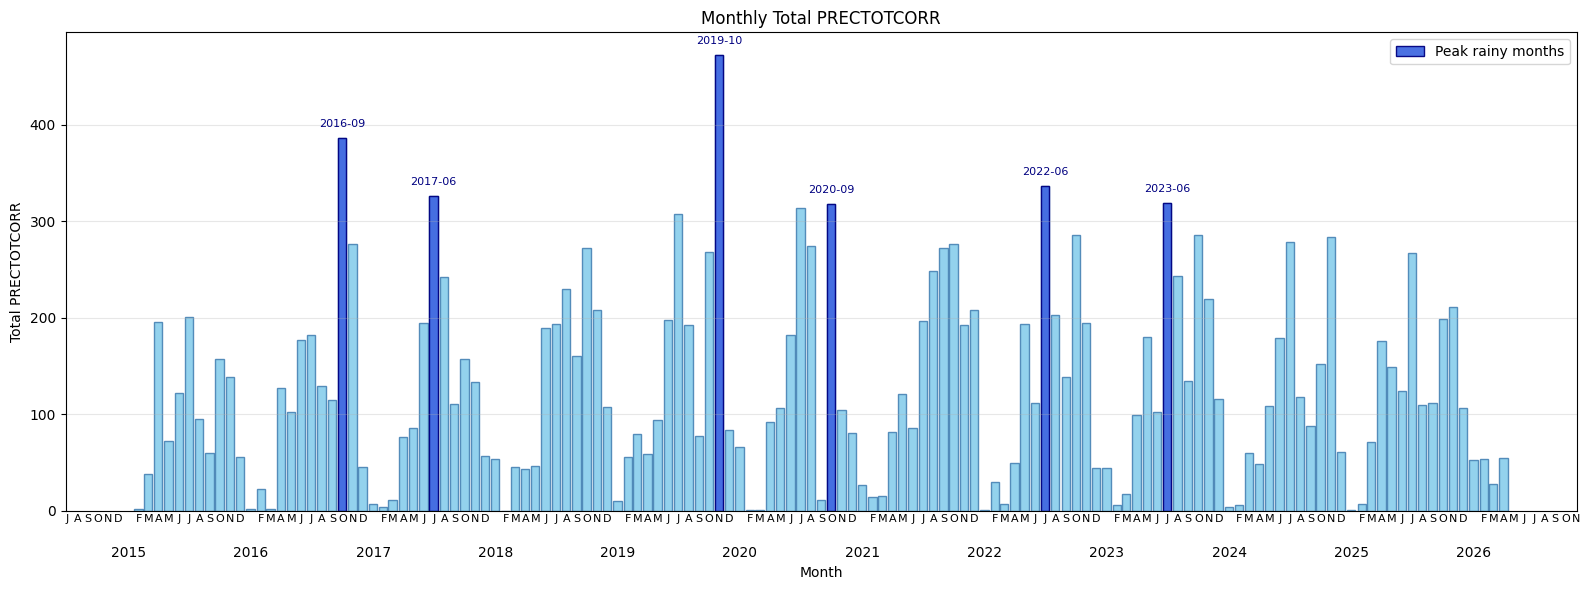

Peak rainy-season months (highest monthly totals):
Date
2016-09-30    386.21
2017-06-30    325.64
2019-10-31    471.90
2020-09-30    318.00
2022-06-30    336.36
2023-06-30    318.53
Name: PRECTOTCORR, dtype: float64


In [41]:
# Monthly total precipitation (PRECTOTCORR)
monthly_total_prectotcorr = df_clean.set_index("Date")["PRECTOTCORR"].resample("ME").sum()

# Pick peak rainy-season months (top 6 wettest months in the full time series)
peak_months = monthly_total_prectotcorr.nlargest(6).sort_index()

plt.figure(figsize=(16, 6))
plt.bar(
    monthly_total_prectotcorr.index,
    monthly_total_prectotcorr.values,
    width=25,
    color="skyblue",
    edgecolor="steelblue",
    alpha=0.9
)

# Highlight and annotate peak months
plt.bar(
    peak_months.index,
    peak_months.values,
    width=25,
    color="royalblue",
    edgecolor="navy",
    alpha=0.95,
    label="Peak rainy months"
)


for dt, val in peak_months.items():
    plt.annotate(
        dt.strftime("%Y-%m"),
        xy=(dt, val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="navy"
    )

ax = plt.gca()

# Year label every year
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("\n%Y"))

# Month labels as first letter (J, F, M, ...)
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(
    FuncFormatter(lambda x, pos: mdates.num2date(x).strftime("%b")[0])
)

ax.tick_params(axis="x", which="major", length=0, pad=14, labelsize=10)
ax.tick_params(axis="x", which="minor", length=0, pad=2, labelsize=8)

plt.title("Monthly Total PRECTOTCORR")
plt.xlabel("Month")
plt.ylabel("Total PRECTOTCORR")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Peak rainy-season months (highest monthly totals):")
print(peak_months)

**Climate Trends and Anomalies: Ethiopia (2015–2026)**

### Precipitation (Monthly Total PRECTOTCORR)
- **Clear seasonal pattern**: Strong seasonal rainfall with the main wet season generally spanning from **June to October** every year. Dark blue bars highlight the peak rainy months.
- **Key anomalies**:
  - Extreme rainfall spike in **October 2019** at **471.90 mm**.
  - Other notable high peaks occurred in **September 2016 (386.21 mm)**, **June 2022 (336.36 mm)**, **June 2017 (325.64 mm)**, **June 2023 (318.53 mm)**, and **September 2020 (318.00 mm)**.
- **Trend**: High inter-annual variability is evident. Some years show highly concentrated, intense wet months (like 2016 and 2019), while others display broader but less extreme peaks.

### Temperature (Monthly Average T2M)
- **Clear seasonal cycle**: Warmer months typically occur in the spring/early summer (**March–June**), while cooler months coincide with the wet season and late fall (**July–December**).
- **Key anomalies**:
  - **Warmest**: March 2026 at **28.92°C**.
  - **Coolest**: August 2020 at **24.42°C**.
- **Trend**: Moderate variability with repetitive seasonal cycles. No strong long-term warming trend is evident across the entire period, though a sharp upward spike is visible at the beginning of 2026.

### Relationship Between Precipitation and Temperature
- **Inverse seasonal relationship**: Peak rainfall months generally coincide with relatively **cooler temperatures**, while the warmest months occur during the drier periods before the heavy rains start.
- **Notable co-occurrences**:
  - The **coolest month (August 2020)** occurred during the heavy rains of that summer, just before the September 2020 rainfall peak. This supports the idea that cloud cover and precipitation act to suppress surface temperatures.
  - The **warmest month (March 2026)** occurred in a dry period before the rainy season set in, allowing intense solar heating.
- **Implication**: Heavy rainfall events tend to moderate temperatures during the wet season, while dry months allow greater temperature extremes.

This analysis highlights strong seasonality and high inter-annual rainfall variability, with temperature anomalies strongly modulated by the annual timing of the rains.

# **Correlation & Relationship Analysis**

### Heatmap of correlations across all numeric columns

In [42]:
# which columns are numberic
df_clean.select_dtypes(include=[np.number]).columns.tolist()

['T2M',
 'T2M_MAX',
 'T2M_MIN',
 'T2M_RANGE',
 'PRECTOTCORR',
 'RH2M',
 'WS2M',
 'WS2M_MAX',
 'PS',
 'QV2M',
 'Month']

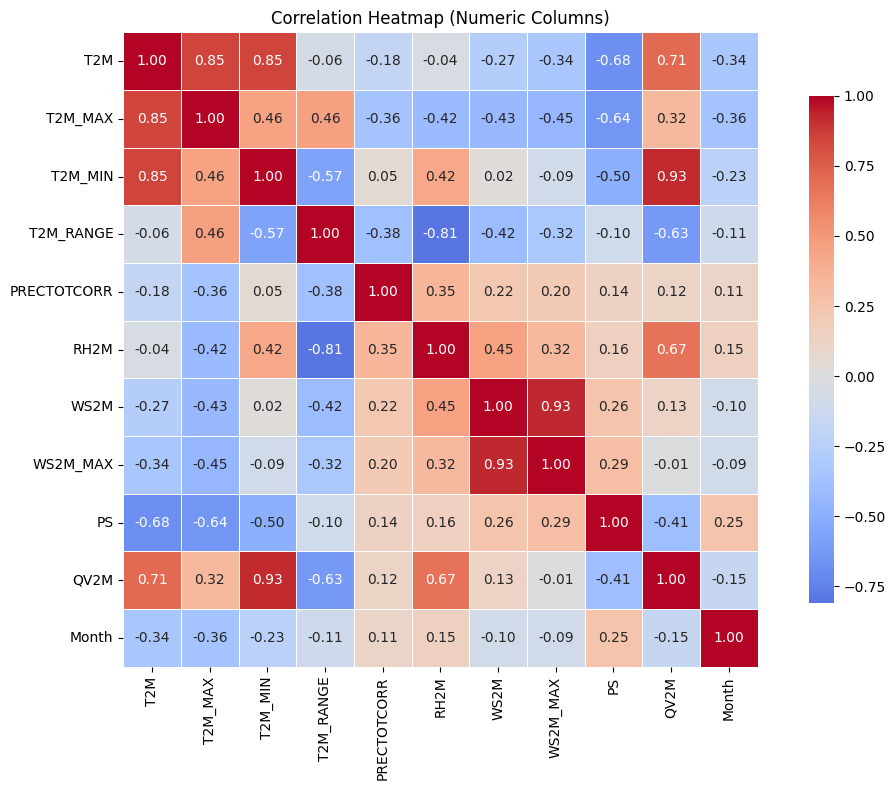

In [43]:
# Correlation heatmap across all numeric columns in df_clean
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.tight_layout()
plt.show()

## Scatter plots

### T2M vs. RH2M and T2M_RANGE vs. WS2M

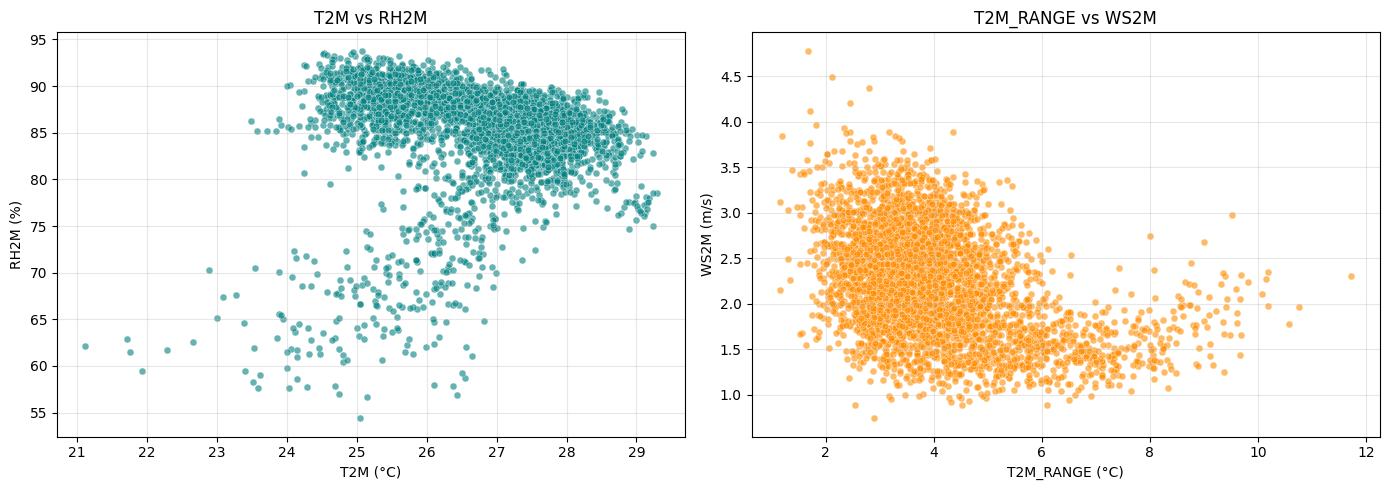

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_clean, x="T2M", y="RH2M",
    alpha=0.6, s=25, ax=axes[0], color="teal"
)
axes[0].set_title("T2M vs RH2M")
axes[0].set_xlabel("T2M (°C)")
axes[0].set_ylabel("RH2M (%)")
axes[0].grid(alpha=0.3)

sns.scatterplot(
    data=df_clean, x="T2M_RANGE", y="WS2M",
    alpha=0.6, s=25, ax=axes[1], color="darkorange"
)
axes[1].set_title("T2M_RANGE vs WS2M")
axes[1].set_xlabel("T2M_RANGE (°C)")
axes[1].set_ylabel("WS2M (m/s)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Three Strongest Correlations

#### 1. Negative Correlation between T2M_RANGE and WS2M (Right Plot)
*   **Identification:** In contrast to previous observations, this specific dataset shows a **negative correlation** between the diurnal temperature range (T2M_RANGE) and wind speed (WS2M). As the temperature range increases from 2°C to 12°C, the wind speed generally settles toward lower values (averaging around 1.5–2.0 m/s).
*   **Interpretation:** This indicates that days with high diurnal temperature variation (often characterized by clear skies and calm nights) are associated with lower wind speeds. Conversely, days with lower temperature ranges likely have higher wind speeds and more cloud cover, which helps regulate temperature extremes and increases atmospheric mixing.

#### 2. Negative Correlation between T2M and RH2M for Temperatures > 25°C (Left Plot, Right Side)
*   **Identification:** In the "T2M vs RH2M" plot, there is a clear negative correlation for the main cluster of data where temperatures exceed **25°C**. The dense upper cloud of points slopes downward significantly as temperatures reach towards 29°C.
*   **Interpretation:** This aligns with the physical relationship where, at a constant moisture level, increasing air temperature lowers relative humidity. This trend is dominant during the warmest parts of the day or warmer seasons represented in the data.

#### 3. Positive Correlation between T2M and RH2M for Temperatures < 25°C (Left Plot, Left Side)
*   **Identification:** For the temperature range between **21°C and 25°C**, particularly for the data points with lower relative humidity (between 55% and 75%), there is a visible **positive trend**. As the temperature increases in this lower bracket, relative humidity values also tend to rise.
*   **Interpretation:** In this specific temperature window, warmer conditions appear to coincide with higher moisture levels. This could reflect regional weather patterns where warmer air masses entering the area are also more humid, or it could represent the transition period as the environment warms up and gathers moisture before reaching peak daily temperatures.

# **Distribution Analysis**

In [46]:
df_clean.head()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


### **Histogram of PRECTOTCORR**

#### Check if the histogram of PRECTOTCORR

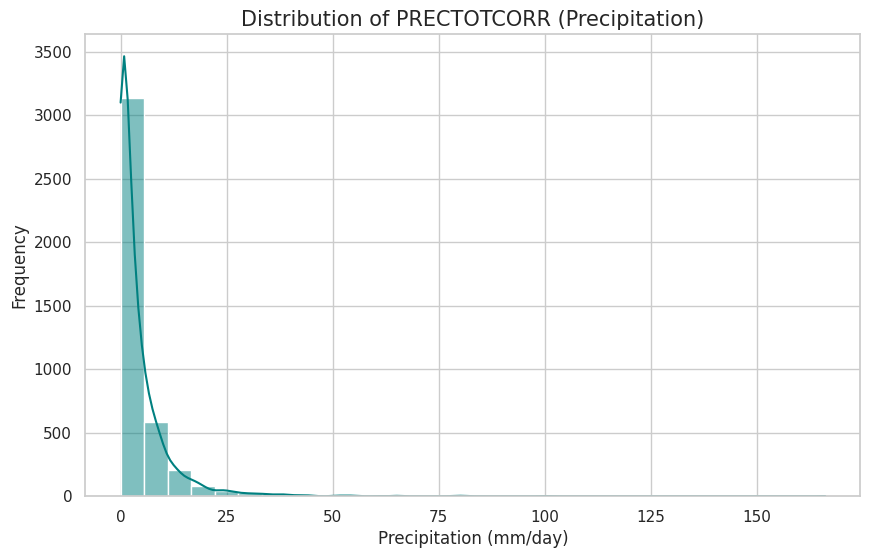

In [47]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'], kde=True, color='teal', bins=30)

plt.title('Distribution of PRECTOTCORR (Precipitation)', fontsize=15)
plt.xlabel('Precipitation (mm/day)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Because the distribution of PRECTOTCORR is heavily skewed we apply log scale to the X-axis to better visualize the distribution.

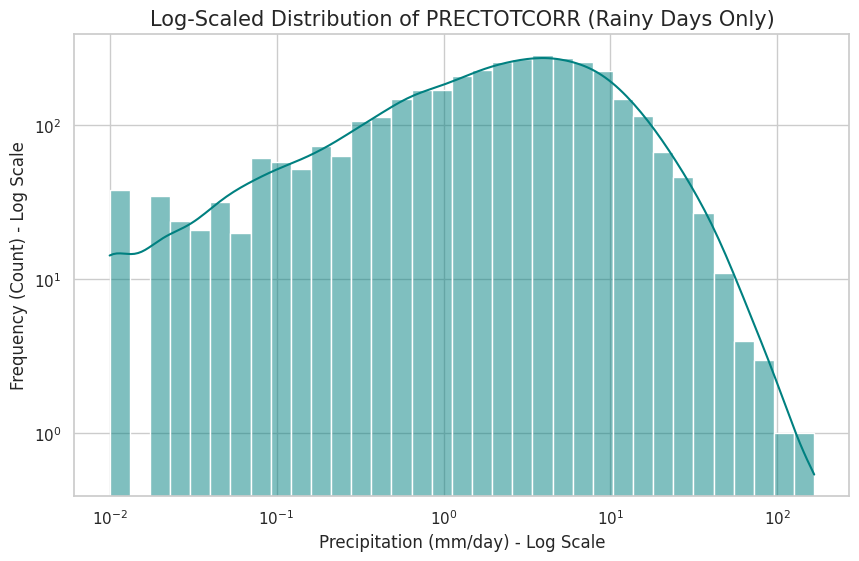

In [48]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6)) 

# Filtering for values > 0 is necessary for log scales because log(0) is undefined
rainy_days = df[df['PRECTOTCORR'] > 0]['PRECTOTCORR']

# log_scale=True automatically calculates log-spaced bins for the X-axis
sns.histplot(rainy_days, kde=True, color='teal', log_scale=True)

# Also applying log scale to the Y-axis (Frequency) to see rare extreme events better
plt.yscale('log')

plt.title('Log-Scaled Distribution of PRECTOTCORR (Rainy Days Only)', fontsize=15)
plt.xlabel('Precipitation (mm/day) - Log Scale', fontsize=12)
plt.ylabel('Frequency (Count) - Log Scale', fontsize=12)

plt.show()

### **Bubble chart**

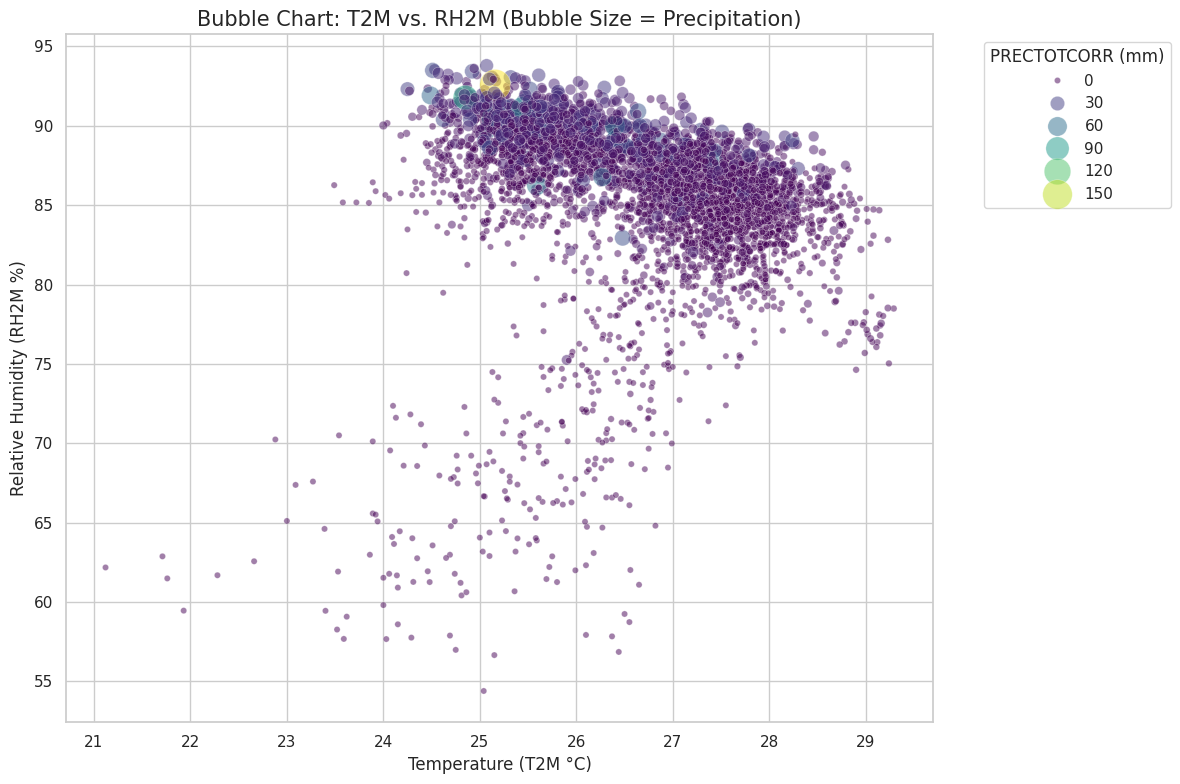

In [49]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

# Create the bubble chart
# s=df['PRECTOTCORR'] * 20: Scale factor to make bubbles visible
# alpha=0.5: Transparency to see overlapping bubbles
# hue='PRECTOTCORR': Colors bubbles by precipitation intensity for better clarity
bubble_plot = sns.scatterplot(
    data=df, 
    x='T2M', 
    y='RH2M', 
    size='PRECTOTCORR', 
    hue='PRECTOTCORR',
    sizes=(20, 500),      
    alpha=0.5,           
    palette='viridis'     
)

# Customizing the chart
plt.title('Bubble Chart: T2M vs. RH2M (Bubble Size = Precipitation)', fontsize=15)
plt.xlabel('Temperature (T2M °C)', fontsize=12)
plt.ylabel('Relative Humidity (RH2M %)', fontsize=12)

# Move the legend outside to avoid overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='PRECTOTCORR (mm)')

plt.tight_layout()
plt.show()

### Interpretation of Bubble Chart: T2M vs. RH2M (Precipitation)

This bubble chart adds a third dimension, **Precipitation (PRECTOTCORR)**, to the relationship between temperature and relative humidity. Here is an analysis of the key patterns observed in this specific dataset:

#### 1. The "Rainy Sweet Spot"
*   **Observation:** The largest bubbles (representing high precipitation, from 60mm to 150mm) are almost exclusively clustered at the very top of the data cloud.
*   **Interpretation:** Significant rainfall events are strictly tied to **high Relative Humidity (above 85–90%)**. Even at temperatures that frequently support rain, precipitation is near zero if the relative humidity drops below 80%. This confirms that near-saturation is a prerequisite for heavy rainfall in this region.

#### 2. Temperature Window for Peak Precipitation
*   **Observation:** The heaviest rainfall events (large yellow and light-green bubbles) are concentrated within a specific "warm" temperature range, roughly **24°C to 28°C**.
*   **Interpretation:** Unlike some cooler climates, the most intense precipitation in this dataset occurs at relatively high temperatures. This suggests a convective tropical or sub-tropical environment where warm, moist air provides the energy and water vapor necessary for extreme rainfall events.

#### 3. Low Humidity = Dry Conditions
*   **Observation:** The vast majority of the chart area, particularly below 80% RH, is populated by tiny purple dots.
*   **Interpretation:** Across a wide range of temperatures (from 21°C to 29°C), if the relative humidity is low, precipitation is consistently absent. This reinforces that humidity is the primary driver and predictor of rainfall, regardless of how warm the air is.

#### 4. The Influence of High Temperature on Rain
*   **Observation:** As temperatures climb toward the far right of the graph (above 27°C), the relative humidity "ceiling" begins to slope downward, and the bubbles generally decrease in size.
*   **Interpretation:** As the air gets even warmer, its capacity to hold moisture increases significantly. Without a massive influx of water vapor, the relative humidity stays below the saturation point needed for heavy rain. Consequently, the very hottest days in this dataset are actually less likely to see extreme precipitation than the slightly "cooler" 25°C days.

### Summary
The chart demonstrates a **strong three-way dependency**: peak precipitation requires a "Goldilocks" zone of warm temperatures (**24–27°C**) combined with extreme relative humidity (**>90%**). Outside of this specific window—either due to lower humidity or excessively high temperatures that prevent saturation—precipitation amounts remain minimal.